Setup and Data Load

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Setting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

Load the CSV file

In [5]:
df = pd.read_csv("adaptive_precision_analysis.csv")

print(f"\nLoaded {len(df)} data points.\n")
print(f"First few rows: \n");
display(df.head(10))


Loaded 1200 data points.

First few rows: 



,Index,Value,XOR_Bits,Leading_Zeros,Trailing_Zeros,Precision
0,0,100.25,64,0,0,64
1,1,100.25,0,0,0,0
2,2,100.25,0,0,0,0
3,3,100.25,0,0,0,0
4,4,100.25,0,0,0,0
5,5,100.25,0,0,0,0
6,6,100.25,0,0,0,0
7,7,100.25,0,0,0,0
8,8,100.25,0,0,0,0
9,9,100.25,0,0,0,0


# Data Overview
Understanding Time Series Characteristics

In [6]:
total_values = len(df)
identical_values = (df['XOR_Bits'] == 0).sum()
changed_values = total_values - identical_values
first_value = 1 #The first value is always stored as raw 64-bit array

#Precision stats
non_zero_precision = df[df['Precision'] > 0]['Precision']
av_precision = non_zero_precision.mean() if len(non_zero_precision) > 0 else 0
max_precision = non_zero_precision.max() if len(non_zero_precision) > 0 else 0
min_precision = non_zero_precision.min() if len(non_zero_precision) > 0 else 0

print("\nCompression Stats")
print("\nValue changes: ")
print(f"Total values: {total_values:,}")
print(f"Identical values: {identical_values:,}, ({100 * (identical_values/total_values):.1f}%)")
print(f"Changed values: {changed_values:,}, ({100 * (changed_values / total_values):.1f}%)")
print("\nPrecision Stats\n")
print(f"Average precision: {av_precision:.1f} bits")
print(f"Maximum precision: {max_precision:.1f} bits")
print(f"Minimum precision: {min_precision:.1f} bits")
print("\nLeading Trailing Zeros\n")
print(f"Average Leading Zeros: {df[df['Leading_Zeros'] > 0]['Leading_Zeros'].mean():.1f}")
print(f"Average Trailing Zeros: {df[df['Trailing_Zeros'] > 0]['Trailing_Zeros'].mean():.1f}")


Compression Stats

Value changes: 
Total values: 1,200
Identical values: 99, (8.2%)
Changed values: 1,101, (91.8%)

Precision Stats

Average precision: 4.8 bits
Maximum precision: 64.0 bits
Minimum precision: 1.0 bits

Leading Trailing Zeros

Average Leading Zeros: 19.9
Average Trailing Zeros: 41.3


# Compression Ratio Calculation
Comparing different encoding strategies

In [7]:
raw_bits = total_values * 64
raw_bytes = raw_bits // 8


basic_bits = 64

for _, row in df.iterrows():

    if row['Index'] == 0:
        continue

    if row['XOR_Bits'] == 0:
        basic_bits += 1

    else:
        basic_bits += 1 + 5 + 6 + row['Precision']


adaptive_bits = 64
prev_precision = 0
prev_lzs = 0
reuse_count = 0

for _, row in df.iterrows():

    if row['Index'] == 0:

        continue

    if row['XOR_Bits'] == 0:

        adaptive_bits += 1  # Control bit

    else:

        # Check if we can reuse precision
        if (row['Leading_Zeros'] >= prev_lzs and
            row['Precision'] <= prev_precision and
            prev_precision > 0):

            # Reuse precision: control + precision_control + data
            adaptive_bits += 1 + 1 + prev_precision
            reuse_count += 1

        else:

            # New precision: control + precision_control + lzs + len + data
            adaptive_bits += 1 + 1 + 5 + 6 + row['Precision']
            prev_precision = row['Precision']
            prev_lzs = row['Leading_Zeros']

basic_bytes = (basic_bits + 7) // 8
adaptive_bytes = (adaptive_bits + 7) // 8

# Calculate ratios
basic_ratio = raw_bytes / basic_bytes
adaptive_ratio = raw_bytes / adaptive_bytes
adaptive_improvement = 100 * (basic_bytes - adaptive_bytes) / basic_bytes


print("COMPRESSION COMPARISON")
print(f"\nUncompressed:")
print(f"Size: {raw_bytes:,} bytes ({raw_bits:,} bits)")
print(f"\nBasic Gorilla:")
print(f"Size: {basic_bytes:,} bytes ({basic_bits:,} bits)")
print(f"Compression ratio: {basic_ratio:.2f}:1")
print(f"Space saved: {100*(1 - 1/basic_ratio):.1f}%")
print(f"\nAdaptive Precision:")
print(f"Size: {adaptive_bytes:,} bytes ({adaptive_bits:,} bits)")
print(f"Compression ratio: {adaptive_ratio:.2f}:1")
print(f"Space saved: {100*(1 - 1/adaptive_ratio):.1f}%")
print(f"Precision reuses: {reuse_count:,} / {changed_values:,} ({100*reuse_count/changed_values:.1f}%)")
print(f"\nImprovement:")
print(f"Adaptive vs Basic: {adaptive_improvement:.1f}% smaller")
print(f"Bits saved per change: {(basic_bits - adaptive_bits) / changed_values:.1f} bits")

COMPRESSION COMPARISON

Uncompressed:
Size: 9,600 bytes (76,800 bits)

Basic Gorilla:
Size: 2,326.0 bytes (18,606.0 bits)
Compression ratio: 4.13:1
Space saved: 75.8%

Adaptive Precision:
Size: 1,912.0 bytes (15,296.0 bits)
Compression ratio: 5.02:1
Space saved: 80.1%
Precision reuses: 1,092 / 1,101 (99.2%)

Improvement:
Adaptive vs Basic: 17.8% smaller
Bits saved per change: 3.0 bits


#Viswualizing Time Series v/ Value Changes

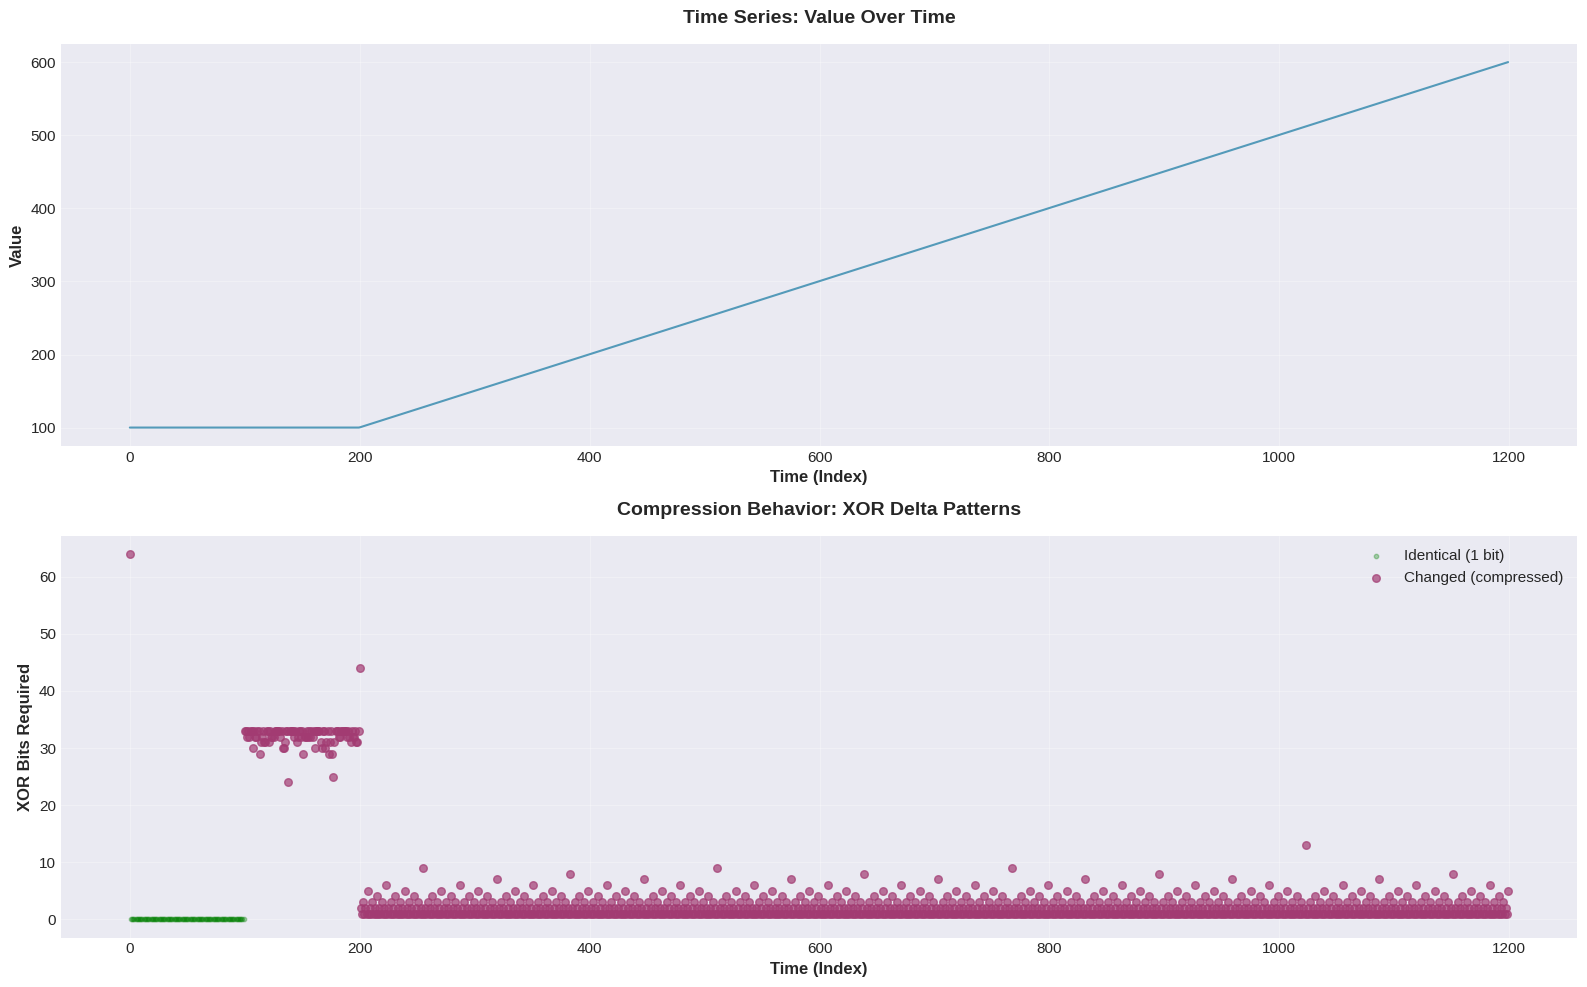


Green dots (identical values): Single control bit (1 bit)
Purple dots (changed values): 1 + 5 + 6 + precision bits


In [8]:
fig, axes = plt.subplots(2, 1, figsize = (16, 10))

ax1 = axes[0]
ax1.plot(df['Index'], df['Value'], linewidth = 1.5, alpha = 0.8, color = '#2E86AB')
ax1.set_xlabel('Time (Index)', fontsize = 12, fontweight = 'bold')
ax1.set_ylabel('Value', fontsize = 12, fontweight = 'bold')
ax1.set_title('Time Series: Value Over Time', fontsize = 14, fontweight = 'bold', pad = 15)
ax1.grid(True, alpha = 0.3)


ax2 = axes[1]
changed = df[df['XOR_Bits'] > 0].copy()
identical = df[df['XOR_Bits'] == 0].copy()

ax2.scatter(identical['Index'], identical['XOR_Bits'],
            s = 10, alpha = 0.3, color = 'green', label = 'Identical (1 bit)')

ax2.scatter(changed['Index'], changed['XOR_Bits'],
            s = 30, alpha = 0.7, color = '#A23B72', label = 'Changed (compressed)')

ax2.set_xlabel('Time (Index)', fontsize = 12, fontweight = 'bold')
ax2.set_ylabel('XOR Bits Required', fontsize = 12, fontweight = 'bold')
ax2.set_title('Compression Behavior: XOR Delta Patterns', fontsize = 14, fontweight = 'bold', pad = 15)
ax2.legend(loc = 'upper right', fontsize = 11)
ax2.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

print(f"\nGreen dots (identical values): Single control bit (1 bit)")
print(f"Purple dots (changed values): 1 + 5 + 6 + precision bits")

#Visualizing Precision Requirement Distribution

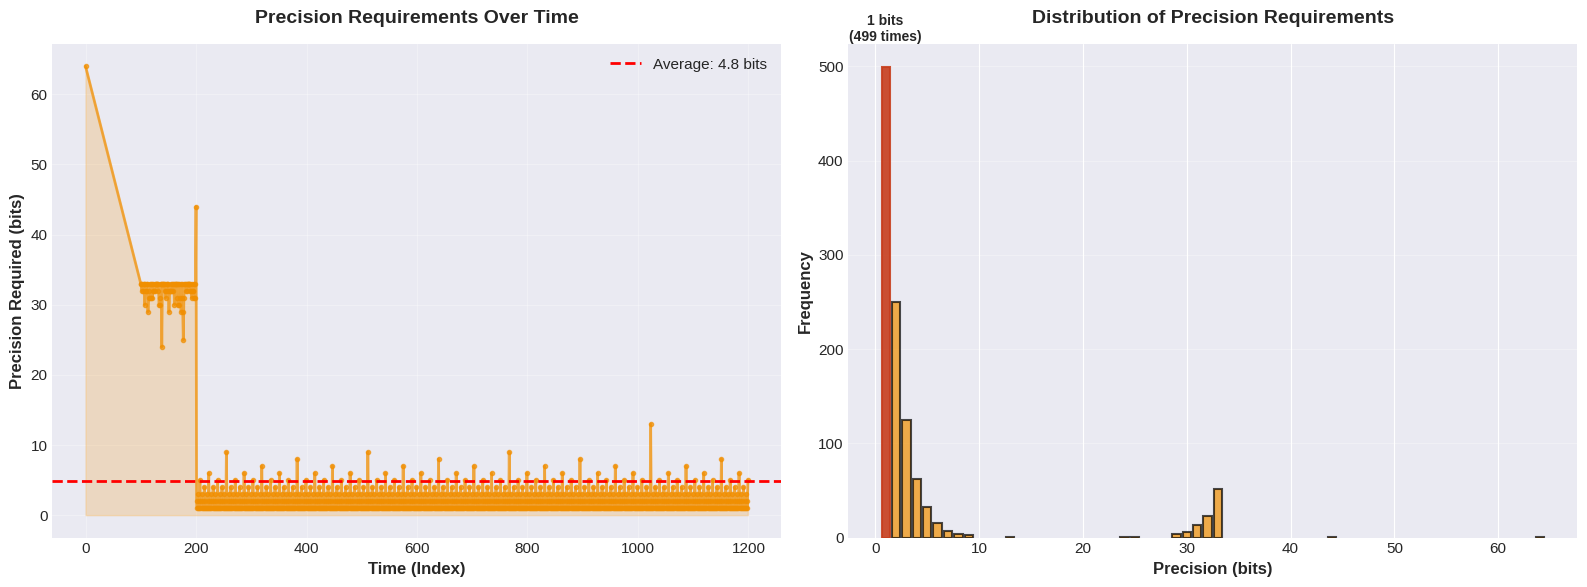


Most common precision: 1 bits (45.3% of changes)
Precision stability: 91.3% (lower std = more stable)


In [9]:
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

ax1 = axes[0]
changed = df[df['Precision'] > 0]
ax1.plot(changed['Index'], changed['Precision'],
         linewidth = 2, alpha = 0.7, color = '#F18F01', marker = 'o', markersize = 3)

ax1.axhline(y = av_precision, color = 'red', linestyle = '--',
            linewidth = 2, label = f'Average: {av_precision:.1f} bits')

ax1.fill_between(changed['Index'], 0, changed['Precision'], alpha = 0.2, color = '#F18F01')

ax1.set_xlabel('Time (Index)', fontsize = 12, fontweight = 'bold')
ax1.set_ylabel('Precision Required (bits)', fontsize = 12, fontweight = 'bold')
ax1.set_title('Precision Requirements Over Time', fontsize = 14, fontweight = 'bold', pad = 15)
ax1.legend(loc='upper right', fontsize = 11)
ax1.grid(True, alpha = 0.3)

# Plot 2: Precision distribution histogram
ax2 = axes[1]
precision_counts = changed['Precision'].value_counts().sort_index()

bars = ax2.bar(precision_counts.index, precision_counts.values,
               color = '#F18F01', alpha = 0.7, edgecolor = 'black', linewidth = 1.5)

# Highlight most common precision
max_idx = precision_counts.idxmax()
max_count = precision_counts.max()
for bar, (prec, count) in zip(bars, precision_counts.items()):
    if prec == max_idx:
        bar.set_color('#C73E1D')
        bar.set_alpha(0.9)

ax2.set_xlabel('Precision (bits)', fontsize = 12, fontweight = 'bold')
ax2.set_ylabel('Frequency', fontsize = 12, fontweight = 'bold')
ax2.set_title('Distribution of Precision Requirements', fontsize = 14, fontweight = 'bold', pad = 15)
ax2.grid(True, alpha = 0.3, axis = 'y')

# Add text annotation for most common
ax2.text(max_idx, max_count * 1.05, f'{max_idx} bits\n({max_count} times)',
         ha = 'center', va = 'bottom', fontsize = 10, fontweight = 'bold')

plt.tight_layout()
plt.show()

print(f"\nMost common precision: {max_idx} bits ({100*max_count/len(changed):.1f}% of changes)")
print(f"Precision stability: {100 - df['Precision'].std():.1f}% (lower std = more stable)")

#Visualizing Leading and Trailing Zero

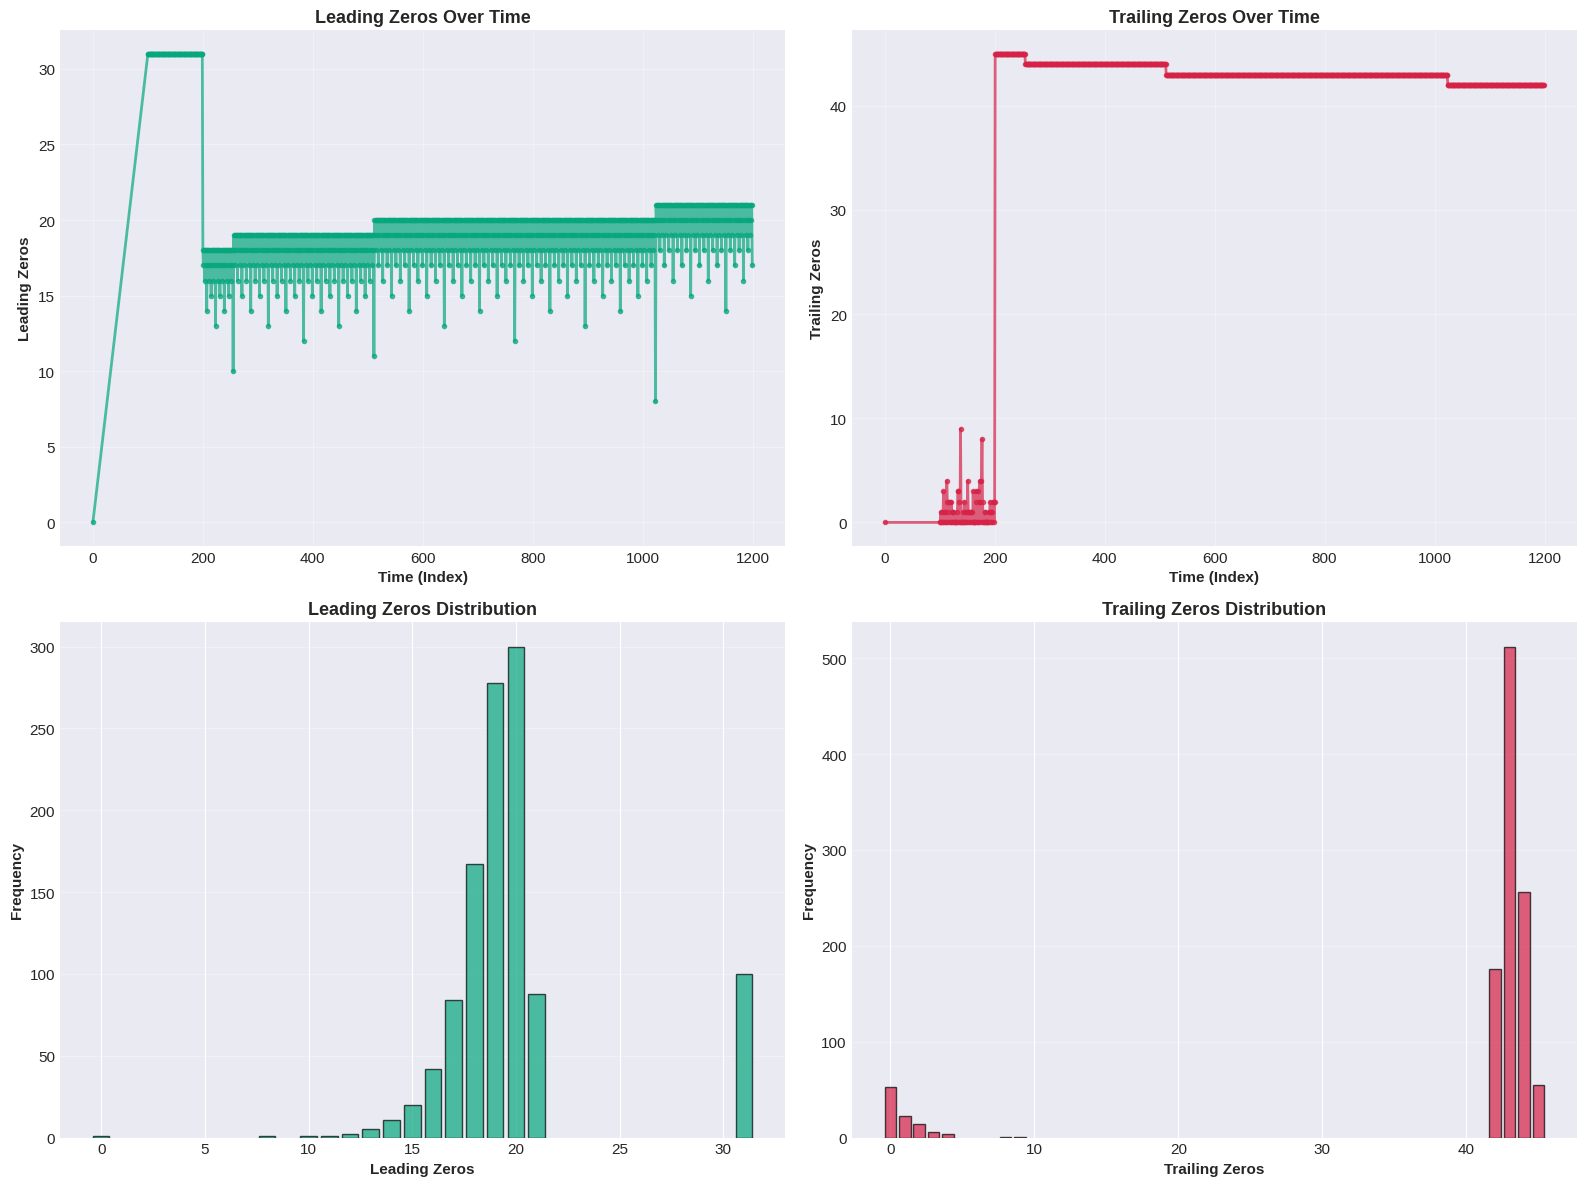


High leading zeros = data locality (similar exponents)

High trailing zeros = precision patterns (similar mantissas)

Compression exploits both patterns


In [10]:
fig, axes = plt.subplots(2, 2, figsize = (16, 12))

changed = df[df['XOR_Bits'] > 0]

# Plot 1: Leading zeros over time
ax1 = axes[0, 0]

ax1.plot(changed['Index'], changed['Leading_Zeros'],
         linewidth = 2, alpha = 0.7, color = '#06A77D', marker = 'o', markersize = 3)
ax1.set_xlabel('Time (Index)', fontsize = 11, fontweight = 'bold')
ax1.set_ylabel('Leading Zeros', fontsize = 11, fontweight = 'bold')
ax1.set_title('Leading Zeros Over Time', fontsize = 13, fontweight = 'bold')
ax1.grid(True, alpha = 0.3)

# Plot 2: Trailing zeros over time
ax2 = axes[0, 1]
ax2.plot(changed['Index'], changed['Trailing_Zeros'],
         linewidth = 2, alpha = 0.7, color = '#D62246', marker = 'o', markersize = 3)
ax2.set_xlabel('Time (Index)', fontsize = 11, fontweight = 'bold')
ax2.set_ylabel('Trailing Zeros', fontsize = 11, fontweight = 'bold')
ax2.set_title('Trailing Zeros Over Time', fontsize = 13, fontweight = 'bold')
ax2.grid(True, alpha = 0.3)

# Plot 3: Leading zeros distribution
ax3 = axes[1, 0]
lz_counts = changed['Leading_Zeros'].value_counts().sort_index()
ax3.bar(lz_counts.index, lz_counts.values,
        color='#06A77D', alpha = 0.7, edgecolor = 'black', linewidth = 1)
ax3.set_xlabel('Leading Zeros', fontsize = 11, fontweight = 'bold')
ax3.set_ylabel('Frequency', fontsize = 11, fontweight = 'bold')
ax3.set_title('Leading Zeros Distribution', fontsize = 13, fontweight = 'bold')
ax3.grid(True, alpha = 0.3, axis = 'y')

# Plot 4: Trailing zeros distribution
ax4 = axes[1, 1]
tz_counts = changed['Trailing_Zeros'].value_counts().sort_index()
ax4.bar(tz_counts.index, tz_counts.values,
        color = '#D62246', alpha = 0.7, edgecolor = 'black', linewidth = 1)
ax4.set_xlabel('Trailing Zeros', fontsize = 11, fontweight = 'bold')
ax4.set_ylabel('Frequency', fontsize = 11, fontweight = 'bold')
ax4.set_title('Trailing Zeros Distribution', fontsize = 13, fontweight = 'bold')
ax4.grid(True, alpha = 0.3, axis = 'y')

plt.tight_layout()
plt.show()

print(f"\nHigh leading zeros = data locality (similar exponents)")
print(f"\nHigh trailing zeros = precision patterns (similar mantissas)")
print(f"\nCompression exploits both patterns")

#Compression Efficiency Heatmap

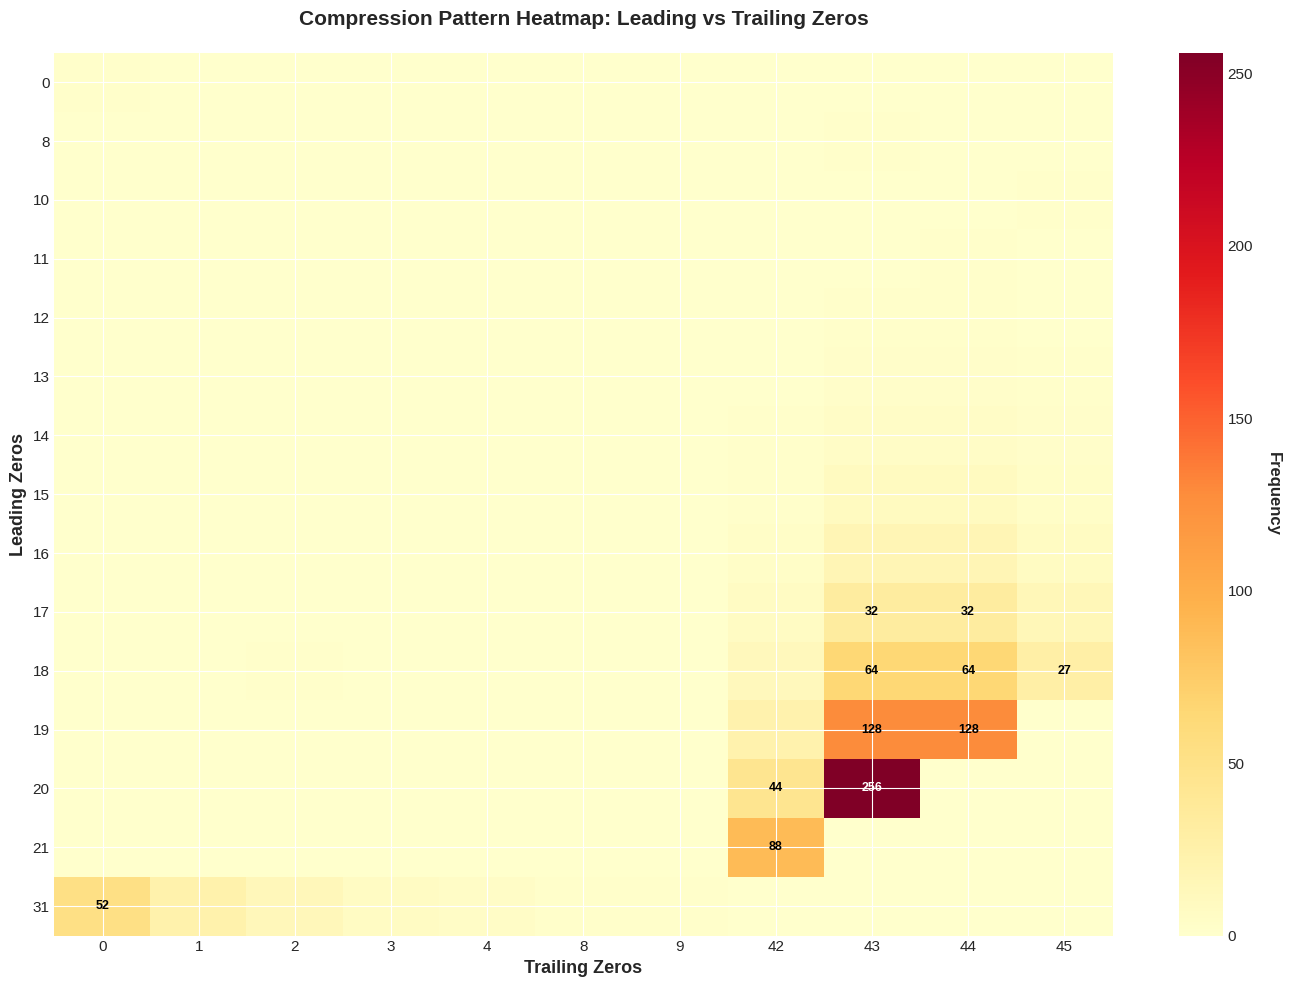


Darker red = more frequent pattern
Top-left (high LZ, low TZ) = best compression
Pattern clusters show data characteristics


In [11]:
# Create 2D histogram of leading vs trailing zeros
changed = df[df['XOR_Bits'] > 0]

if len(changed) > 0:

    # Create pivot table
    pivot = changed.groupby(['Leading_Zeros', 'Trailing_Zeros']).size().reset_index(name = 'count')
    pivot_table = pivot.pivot(index = 'Leading_Zeros', columns = 'Trailing_Zeros', values = 'count').fillna(0)

    fig, ax = plt.subplots(figsize = (14, 10))

    # Create heatmap
    im = ax.imshow(pivot_table, cmap = 'YlOrRd', aspect = 'auto', interpolation = 'nearest')

    # Set ticks
    ax.set_xticks(np.arange(len(pivot_table.columns)))
    ax.set_yticks(np.arange(len(pivot_table.index)))
    ax.set_xticklabels(pivot_table.columns)
    ax.set_yticklabels(pivot_table.index)

    # Labels
    ax.set_xlabel('Trailing Zeros', fontsize = 13, fontweight = 'bold')
    ax.set_ylabel('Leading Zeros', fontsize = 13, fontweight = 'bold')
    ax.set_title('Compression Pattern Heatmap: Leading vs Trailing Zeros',
                 fontsize = 15, fontweight = 'bold', pad = 20)

    # Colorbar
    cbar = plt.colorbar(im, ax = ax)
    cbar.set_label('Frequency', rotation = 270, labelpad = 20, fontsize = 12, fontweight = 'bold')

    # Add text annotations for high-frequency cells
    for i in range(len(pivot_table.index)):

        for j in range(len(pivot_table.columns)):

            count = int(pivot_table.iloc[i, j])
            if count > pivot_table.values.max() * 0.1:  # Show top 10%

                text = ax.text(j, i, count, ha = "center", va = "center",
                              color = "white" if count > pivot_table.values.max()*0.5 else "black",
                              fontsize = 9, fontweight = 'bold')

    plt.tight_layout()
    plt.show()

    print(f"\nDarker red = more frequent pattern")
    print(f"Top-left (high LZ, low TZ) = best compression")
    print(f"Pattern clusters show data characteristics")
else:
    print("No changed values to visualize.")

#Bit Saving Analysis

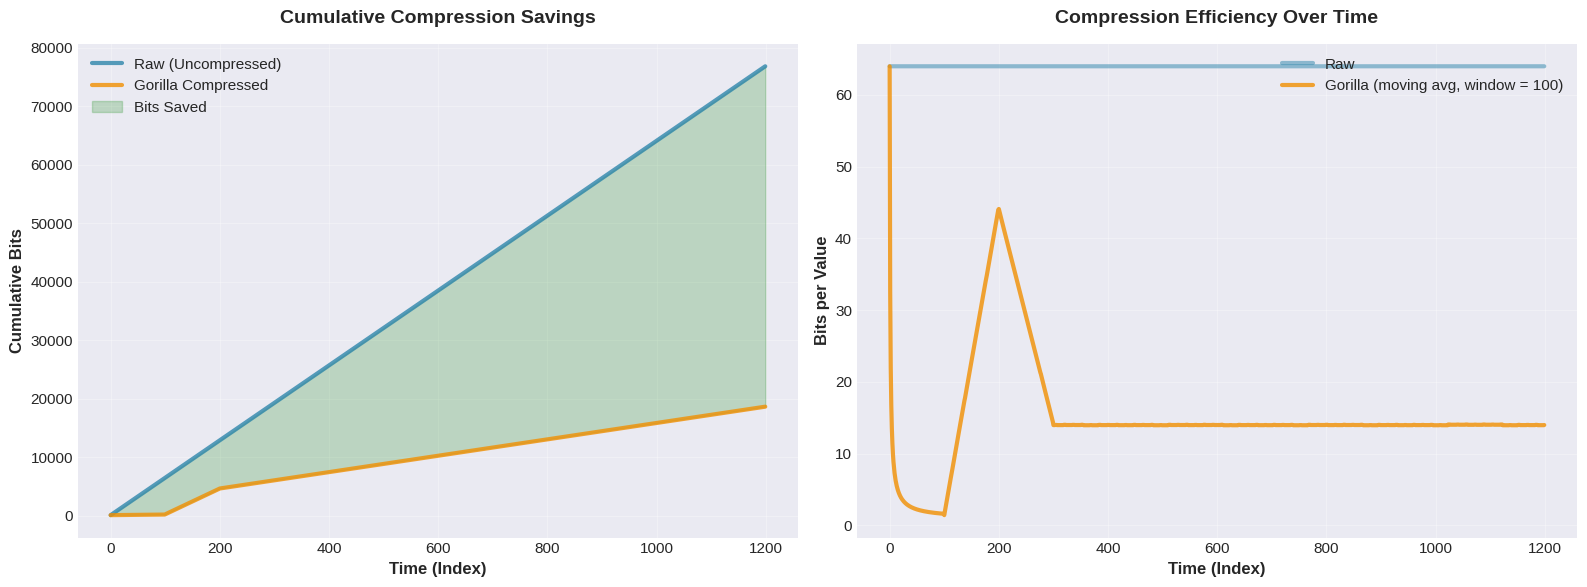


Total bits saved: 58,194 bits (75.8%)

Average bits per value: 15.51 bits (vs 64 raw)


In [12]:
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Calculate bits per encoding type
df_analysis = df.copy()
df_analysis['Raw_Bits'] = 64  # Each value as raw double
df_analysis['Basic_Bits'] = df_analysis.apply(
    lambda row: 64 if row['Index'] == 0 else (
        1 if row['XOR_Bits'] == 0 else 1 + 5 + 6 + row['Precision']
    ), axis = 1
)

# Cumulative bits
df_analysis['Cumulative_Raw'] = df_analysis['Raw_Bits'].cumsum()
df_analysis['Cumulative_Basic'] = df_analysis['Basic_Bits'].cumsum()

# Plot 1: Cumulative bits comparison
ax1 = axes[0]
ax1.plot(df_analysis['Index'], df_analysis['Cumulative_Raw'],
         linewidth = 3, alpha = 0.8, label = 'Raw (Uncompressed)', color = '#2E86AB')

ax1.plot(df_analysis['Index'], df_analysis['Cumulative_Basic'],
         linewidth = 3, alpha = 0.8, label = 'Gorilla Compressed', color = '#F18F01')

ax1.fill_between(df_analysis['Index'],
                 df_analysis['Cumulative_Basic'],
                 df_analysis['Cumulative_Raw'],
                 alpha = 0.2, color = 'green', label = 'Bits Saved')

ax1.set_xlabel('Time (Index)', fontsize = 12, fontweight = 'bold')
ax1.set_ylabel('Cumulative Bits', fontsize = 12, fontweight = 'bold')
ax1.set_title('Cumulative Compression Savings', fontsize = 14, fontweight = 'bold', pad = 15)
ax1.legend(loc = 'upper left', fontsize = 11)
ax1.grid(True, alpha = 0.3)

# Plot 2: Bits per value
ax2 = axes[1]
window_size = 100
df_analysis['Bits_Per_Value_Raw'] = 64
df_analysis['Bits_Per_Value_Basic'] = df_analysis['Basic_Bits'].rolling(
    window = window_size, min_periods = 1).mean()

ax2.plot(df_analysis['Index'], df_analysis['Bits_Per_Value_Raw'],
         linewidth = 3, alpha = 0.5, label = 'Raw', color = '#2E86AB')
ax2.plot(df_analysis['Index'], df_analysis['Bits_Per_Value_Basic'],
         linewidth = 3, alpha = 0.8, label = f'Gorilla (moving avg, window = {window_size})',
         color = '#F18F01')

ax2.set_xlabel('Time (Index)', fontsize = 12, fontweight = 'bold')
ax2.set_ylabel('Bits per Value', fontsize = 12, fontweight = 'bold')
ax2.set_title('Compression Efficiency Over Time', fontsize = 14, fontweight = 'bold', pad = 15)
ax2.legend(loc = 'upper right', fontsize = 11)
ax2.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

final_savings = df_analysis['Cumulative_Raw'].iloc[-1] - df_analysis['Cumulative_Basic'].iloc[-1]
final_savings_pct = 100 * final_savings / df_analysis['Cumulative_Raw'].iloc[-1]
print(f"\nTotal bits saved: {int(final_savings):,} bits ({final_savings_pct:.1f}%)")
print(f"\nAverage bits per value: {df_analysis['Basic_Bits'].mean():.2f} bits (vs 64 raw)")

#Stats Summary

In [13]:
# Create summary table
summary_data = {
    'Metric': [
        'Total Values',
        'Identical Values',
        'Changed Values',
        'Avg Precision (bits)',
        'Avg Leading Zeros',
        'Avg Trailing Zeros',
        'Raw Size (bytes)',
        'Compressed Size (bytes)',
        'Compression Ratio',
        'Space Saved'
    ],
    'Value': [
        f"{total_values:,}",
        f"{identical_values:,} ({100*identical_values/total_values:.1f}%)",
        f"{changed_values:,} ({100*changed_values/total_values:.1f}%)",
        f"{av_precision:.1f}",
        f"{df[df['Leading_Zeros'] > 0]['Leading_Zeros'].mean():.1f}",
        f"{df[df['Trailing_Zeros'] > 0]['Trailing_Zeros'].mean():.1f}",
        f"{raw_bytes:,}",
        f"{basic_bytes:,}",
        f"{basic_ratio:.2f}:1",
        f"{100 * (1 - 1/basic_ratio):.1f}%"
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\nFINAL SUMMARY\n")

display(summary_df.style.hide(axis = 'index').set_properties(**{
    'text-align': 'left',
    'font-size': '12pt'
}))


FINAL SUMMARY



Metric,Value
Total Values,"1,200"
Identical Values,99 (8.2%)
Changed Values,"1,101 (91.8%)"
Avg Precision (bits),4.8
Avg Leading Zeros,19.9
Avg Trailing Zeros,41.3
Raw Size (bytes),"9,600"
Compressed Size (bytes),"2,326.0"
Compression Ratio,4.13:1
Space Saved,75.8%
